# Decoding stimuli from PCs
This file performs PCA on the neural data, and examines whether high variance or low variance PCs contribute more to decoding accuracy. 

## Preprocessing data
Here we load datasets from 7 recordings and define a function for extracting the data and performing PCA on the neural responses. 

Note: ~2800 images were shown in the same order for multiple trials. The number of trial repeats varies per dataset. The trials were split in half to define a first repeat and second repeat to later cross-validate PC responses. 

In [2]:
# Imports
from scipy import io
import os
import numpy as np
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.decomposition import PCA
from scipy.sparse.linalg import eigsh


# Load files
dat = io.loadmat('/Users/jessicalau/natimg2800_M170714_MP032_2017-09-14.mat')
dat2 = io.loadmat('/Users/jessicalau/natimg2800_M170717_MP034_2017-09-11.mat')
dat3 = io.loadmat('/Users/jessicalau/natimg2800_M170714_MP032_2017-08-07.mat')
dat4 = io.loadmat('/Users/jessicalau/natimg2800_M161025_MP030_2017-05-29.mat')
dat5 = io.loadmat('/Users/jessicalau/natimg2800_M170717_MP033_2017-08-20.mat')
dat6 = io.loadmat('/Users/jessicalau/natimg2800_M160825_MP027_2016-12-14.mat')
dat7 = io.loadmat('/Users/jessicalau/natimg2800_M170604_MP031_2017-06-28.mat')

# Preprocess data (these preprocessing steps were copied from their notebooks)
def preprocess(dat):
    resp  = dat['stim'][0]['resp'][0]    # Neural responses: stim x neurons
    spont = dat['stim'][0]['spont'][0]   # Spontaneous activity: timepoints x neurons
    istim = dat['stim'][0]['istim'][0].astype(np.int32)[:, 0] - 1   # Stimulus IDs (subtract 1 to use 0-based indexing)

    # -- Remove blank-stimulus trials -- 
    nimg = istim.max()              # this is index where blank images start
    resp  = resp[istim < nimg, :]   # remove blank stimuli from responses
    istim = istim[istim < nimg]     # remove blank stimuli from stimulus IDs

    # -- Z-score responses using spontaneous activity stats -- 
    mu = spont.mean(axis=0)         # per-neuron mean of spont. activity
    sd = spont.std(axis=0) + 1e-6   # per-neuron std of spont. activity
    resp  = (resp  - mu) / sd       
    spont = (spont - mu) / sd       


    # -- Regress out top 32 dimensions of spontaneous activity --
    # eigsh gives the top-k eigenvectors of the spontaneous covariance matrix;
    # these capture shared fluctuations (arousal, drift) unrelated to the stimulus.
    # Projecting them out of resp removes this noise source.
    sv, u = eigsh(spont.T @ spont, k=32)   # u: (n_neurons x 32)
    resp  = resp - (resp @ u) @ u.T         # subtract projection onto spontaneous subspace

    # -- Remove any residual per-neuron offset after z-scoring -- 
    resp -= resp.mean(axis=0)

    # -- Split trials into two independent repeats per stimulus -- 
    # sresp[0, n] and sresp[1, n] are the mean responses to image n from the first and second halves of its trials respectively
    NN    = resp.shape[1]
    sresp = np.zeros((2, nimg, NN), np.float64)
    inan  = np.zeros(nimg, dtype=bool)
    for n in range(nimg):
        ist = (istim == n).nonzero()[0]          # indices of all trials for image n
        i1, i2 = ist[:len(ist)//2], ist[len(ist)//2:]
        if len(i1) < 1 or len(i2) < 1:          # skip images with fewer than 2 trials
            inan[n] = True
        else:
            sresp[0, n] = resp[i1].mean(axis=0)  # repeat 0: average over first-half trials
            sresp[1, n] = resp[i2].mean(axis=0)  # repeat 1: average over second-half trials
    sresp = sresp[:, ~inan, :]                   # drop images that lacked two repeats

    # ── PCA fitted on repeat 0, applied to both repeats ──────────────────────
    # Fitting only on repeat 0 keeps repeat 1 fully held out for decoding evaluation
    # n_pc = nstims - 1: maximum rank of the (nstims x nstims) covariance matrix
    n_pc    = sresp.shape[1] - 1
    pca     = PCA(n_components=n_pc).fit(sresp[0])
    scores0 = pca.transform(sresp[0])          # (nstims x n_pc) PC projections, repeat 0
    scores1 = pca.transform(sresp[1])          # (nstims x n_pc) PC projections, repeat 1

    return sresp, scores0, scores1, n_pc, sresp.shape[1]


datasets  = [dat, dat2, dat3, dat4, dat5, dat6, dat7]
mouse_ids = ['MP032-Sep14', 'MP034-Sep11', 'MP032-Aug07',
             'MP030-May29', 'MP033-Aug20', 'MP027-Dec14', 'MP031-Jun28']

## 1. Decoding accuracy based on individual PCs
All neural responses (for both repeats) are projected into PC space using the preprocess(dat) function. We now decode stimuli using these PCs. The decoding mechanism we use for single PCs (1-dimensional) is simply finding the stimulus across the two repeats that minimizes the distance between the two scores. 

Here, we evaluate the efficient coding vs. low-dimensional hypothesis by seeing if decoding performance is concentrated in top PCs and decays rapidly (low-D hypothesis) or is evenly distributed (efficient coding). However, decoding using individual PCs is going to be poor regardless, so we can't infer too much from these plots. 

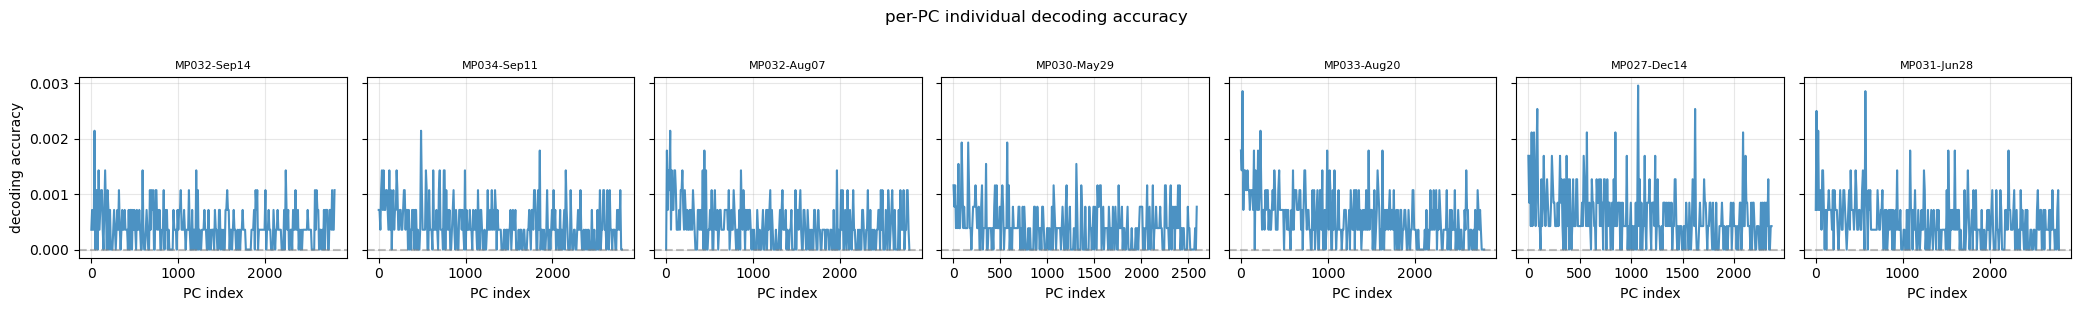

In [ ]:
# Plot 1: per-PC individual decoding — one subplot per mouse
fig, axes = plt.subplots(1, 7, figsize=(21, 3), sharey=True)

for ax, d, label in zip(axes, datasets, mouse_ids):
    sresp, scores0, scores1, n_pc, nstims = preprocess(d)
    pc_indices = np.round(np.linspace(0, n_pc - 1, 300)).astype(int)   # take 300 evenly spaced PCs
    acc_per_pc = np.zeros(len(pc_indices))
    for i, k in enumerate(pc_indices):
        # For each repeat 0 stimulus, find repeat 1 stimulus with closest PC score on k-th PC
        diff = scores0[:, k:k+1] - scores1[:, k]
        # Compute decoding accuracy as fraction of stimuli for which closest match is the same stimulus (diagonal of diff)
        acc_per_pc[i] = ((diff**2).argmin(axis=1) == np.arange(nstims)).mean()
    ax.plot(pc_indices + 1, acc_per_pc, alpha=0.8)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(label, fontsize=8)
    ax.set_xlabel('PC index')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('decoding accuracy')
fig.suptitle('per-PC individual decoding accuracy', y=1.02)
plt.tight_layout()
plt.savefig('Fig1.png')
plt.show()

## 2. Decoding using high-variance PCs vs. low-variance PCs
We wanted to investigate how subsets of high-variance or low-variance PCs would contribute to decoding accuracy. Here we take an increasing number of PCs from the PCs sorted from either high to low variance (top PCs) or sorted from low to high variance (bottom PCs). The higher curve will show which subset encodes stimulus identity better. Note: decoding by chance would be close to zero in these graphs (1/2800 ~ 0.0004). 

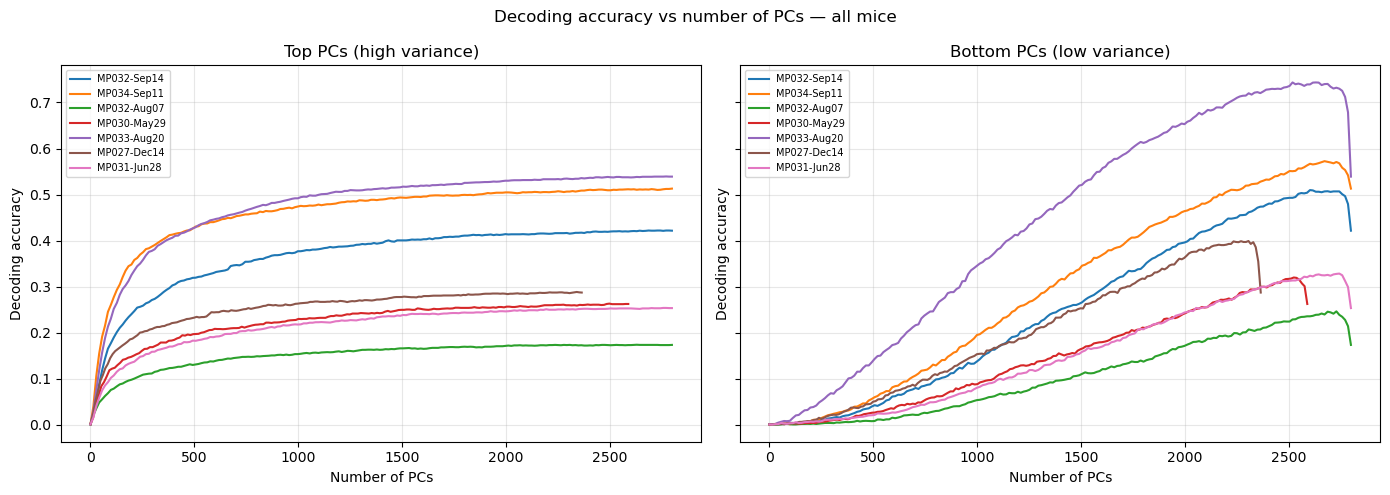

In [4]:
# Plot 2: top vs bottom PC decoding for all mice
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for d, label in zip(datasets, mouse_ids):
    sresp, scores0, scores1, n_pc, nstims = preprocess(d)
    
    # Number of PCs to take
    ks = np.round(np.linspace(1, n_pc, 200)).astype(int)
    acc_top = np.zeros(len(ks))
    acc_bottom = np.zeros(len(ks))

    for i, k in enumerate(ks):
        # Compute dot products between top k PCs
        cc = scores0[:, :k] @ scores1[:, :k].T
        # Compute decoding accuracy using cc
        acc_top[i] = (cc.argmax(axis=1) == np.arange(nstims)).mean()
        # Same for bottom k PCs
        cc = scores0[:, -k:] @ scores1[:, -k:].T
        acc_bottom[i] = (cc.argmax(axis=1) == np.arange(nstims)).mean()
    axes[0].plot(ks, acc_top,    label=label)
    axes[1].plot(ks, acc_bottom, label=label)

for ax, title in zip(axes, ['Top PCs (high variance)', 'Bottom PCs (low variance)']):
    ax.set_xlabel('Number of PCs')
    ax.set_ylabel('Decoding accuracy')
    ax.set_title(title)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Decoding accuracy vs number of PCs — all mice')
plt.tight_layout()
plt.savefig('Fig2.png')
plt.show()

## 2a. Investigating signal to noise ratio per PC
We want to investigate 
Signal variance = cross-validated variance: (scores0 * scores1).mean(axis=0) (noise cancels across independent repeats)

Noise variance  = total variance - signal variance

SNR             = signal / noise

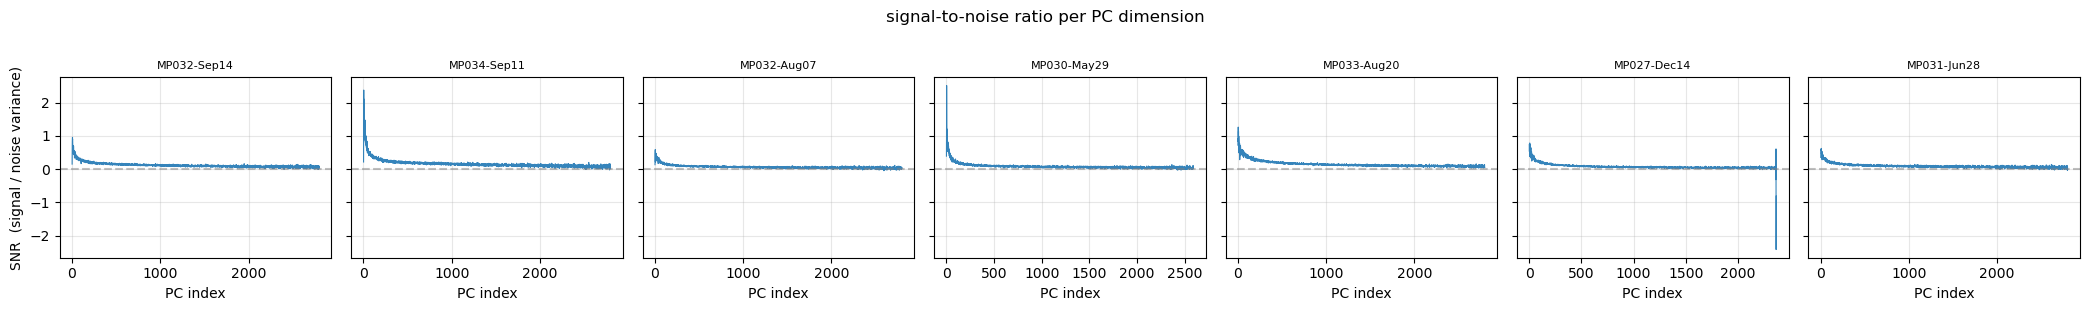

In [ ]:
# Plot 2a: SNR per PC dimension for all mice
fig, axes = plt.subplots(1, 7, figsize=(21, 3), sharey=True)

for ax, d, label in zip(axes, datasets, mouse_ids):
    sresp, scores0, scores1, n_pc, nstims = preprocess(d)

    sig_var   = (scores0 * scores1).mean(axis=0)           # cross-validated signal per PC
    total_var = scores0.var(axis=0)                        # total variance per PC
    noise_var = total_var - sig_var                        # noise = total - signal
    snr       = sig_var / (noise_var + 1e-12)              # SNR per PC

    pc_indices = np.arange(1, n_pc + 1)
    ax.plot(pc_indices, snr, lw=0.8, alpha=0.9)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(label, fontsize=8)
    ax.set_xlabel('PC index')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('SNR  (signal / noise variance)')
fig.suptitle('signal-to-noise ratio per PC dimension', y=1.02)
plt.tight_layout()
plt.savefig('Fig2a.png')
plt.show()

### 2b. Investigating whether number of trials in each dataset impacts cross-mouse differences in decoding
We wanted to check whether the differences we are observing in decoding accuracy across mice are simply due to the fact that some datasets include different numbers of trials. With more trials per stimulus, the averaged responses used for PCA are less noisy, which could inflate decoding accuracy independently of any true biological differences. To test this, we plotted final decoding accuracy (using all PCs) against mean trials per stimulus across the seven mice.

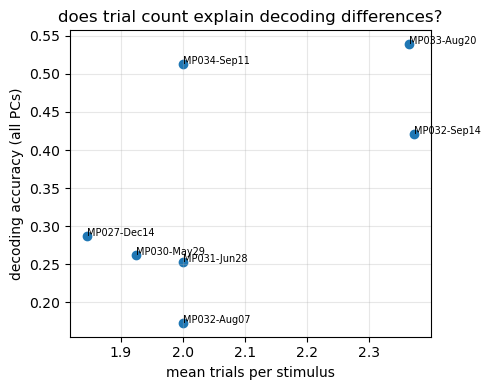

In [ ]:
# Plot 2b: does trial count explain decoding differences
mean_trials = []
final_acc = []

for d, label in zip(datasets, mouse_ids):
    # mean trials per stimulus
    istim = d['stim'][0]['istim'][0].astype(np.int32)[:, 0] - 1  # stimulus IDs (subtract 1 for 0-based indexing)
    nimg = istim.max()
    # Sum over how many trials image n was shown and then average over all images (to get mean trials per stimulus)
    mean_trials.append(np.mean([(istim == n).sum() for n in range(nimg)]))
    
    # decoding accuracy using all PCs
    sresp, scores0, scores1, n_pc, nstims = preprocess(d)
    cc = scores0 @ scores1.T
    final_acc.append((cc.argmax(axis=1) == np.arange(nstims)).mean())

plt.figure(figsize=(5, 4))
plt.scatter(mean_trials, final_acc)
for i, label in enumerate(mouse_ids):
    plt.annotate(label, (mean_trials[i], final_acc[i]), fontsize=7, ha='left')
plt.xlabel('mean trials per stimulus')
plt.ylabel('decoding accuracy (all PCs)')
plt.title('Impact of trial count on decoding differences')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Fig2b.png')
plt.show()

## 3. Inspecting top vs. bottom PC curve in one mouse

### 3a. Identifying range where the bottom PC curve starts performing better

decoding accuracy (all PCs): 0.421


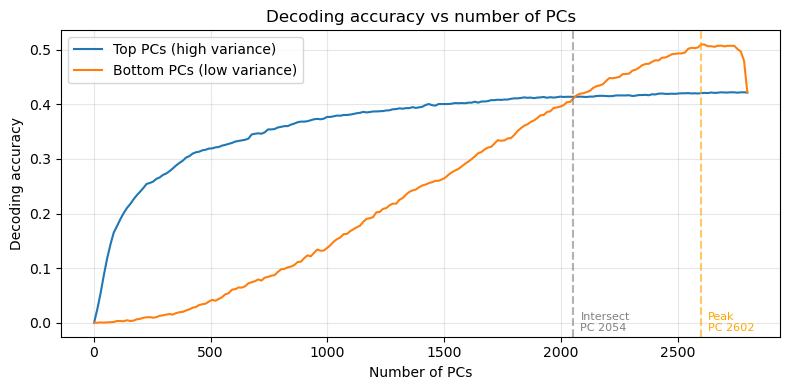

Lines intersect at k = 2054
Bottom PCs peak at k = 2602  (PC index 198 to 2799)


In [ ]:
# Get responses for first dataframe (M032-Sep14)
sresp, scores0, scores1, n_pc, nstims = preprocess(dat)

# single-number decoding accuracy (all PCs using dot products)
cc = scores0 @ scores1.T
cc /= (scores0**2).sum()   # divide cross-correlation matrix by total variance in first response (max will be the same)
cc /= (scores1**2).sum()   # divide cross-correlation matrix by total variance in second response
nstims = sresp.shape[1]
print('decoding accuracy (all PCs): %2.3f' % (cc.argmax(axis=1) == np.arange(0, nstims, 1, int)).mean())

# decoding accuracy vs number of PCs (top vs bottom variance)
ks = np.round(np.linspace(1, n_pc, 200)).astype(int)   # generate 200 evenly spaced values
acc_top = np.zeros(len(ks))
acc_bottom = np.zeros(len(ks))

for i, k in enumerate(ks):
    # Dot product between scores up to k-th PC
    cc = scores0[:, :k] @ scores1[:, :k].T
    # Compute decoding accuracy using cc
    acc_top[i] = (cc.argmax(axis=1) == np.arange(nstims)).mean()
    # Dot product between scores of bottom k PCs
    cc = scores0[:, -k:] @ scores1[:, -k:].T
    # Compute decoding accuracy using cc
    acc_bottom[i] = (cc.argmax(axis=1) == np.arange(nstims)).mean()

# Find intersection: where acc_bottom first exceeds acc_top
diff = acc_bottom - acc_top
crossings = np.where(np.diff(np.sign(diff)) > 0)[0]
intersect_k = ks[crossings[0]] if len(crossings) > 0 else None

# find peak of acc_bottom (orange line)
peak_idx = np.argmax(acc_bottom)
peak_k = ks[peak_idx]

plt.figure(figsize=(8, 4))
plt.plot(ks, acc_top, label='Top PCs (high variance)')
plt.plot(ks, acc_bottom, label='Bottom PCs (low variance)')

offset = 30  # adjust to taste

if intersect_k is not None:
    plt.axvline(intersect_k, color='gray', linestyle='--', alpha=0.6)
    plt.text(intersect_k + offset, plt.ylim()[0] + 0.01, f'Intersect\nPC {intersect_k}',
             ha='left', fontsize=8, color='gray')

plt.axvline(peak_k, color='orange', linestyle='--', alpha=0.6)
plt.text(peak_k + offset, plt.ylim()[0] + 0.01, f'Peak\nPC {peak_k}',
         ha='left', fontsize=8, color='orange')

plt.xlabel('Number of PCs')
plt.ylabel('Decoding accuracy')
plt.title('Decoding accuracy vs number of PCs')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('Fig3a.png')
plt.tight_layout()
plt.show()

print(f'Lines intersect at k = {intersect_k}')
print(f'Bottom PCs peak at k = {peak_k}  (PC index {n_pc - peak_k + 1} to {n_pc})')

### 3b. Inspecting the cc matrices used to decode
We wanted to see why the orange curve suddenly drops off in accuracy when it includes the top 198 (high-variance) PCs. By inspecting the cross-correlation matrices, we can see whether the diagonal (which should be clearly illuminated if the decoder is good) is corrupted when we add new PCs. For example, if we see that certain stimuli have bands across the matrix, that means they are correlating with all stimuli across the two repeats, and causing the decoder to choose those dominating stimuli incorrectly. 

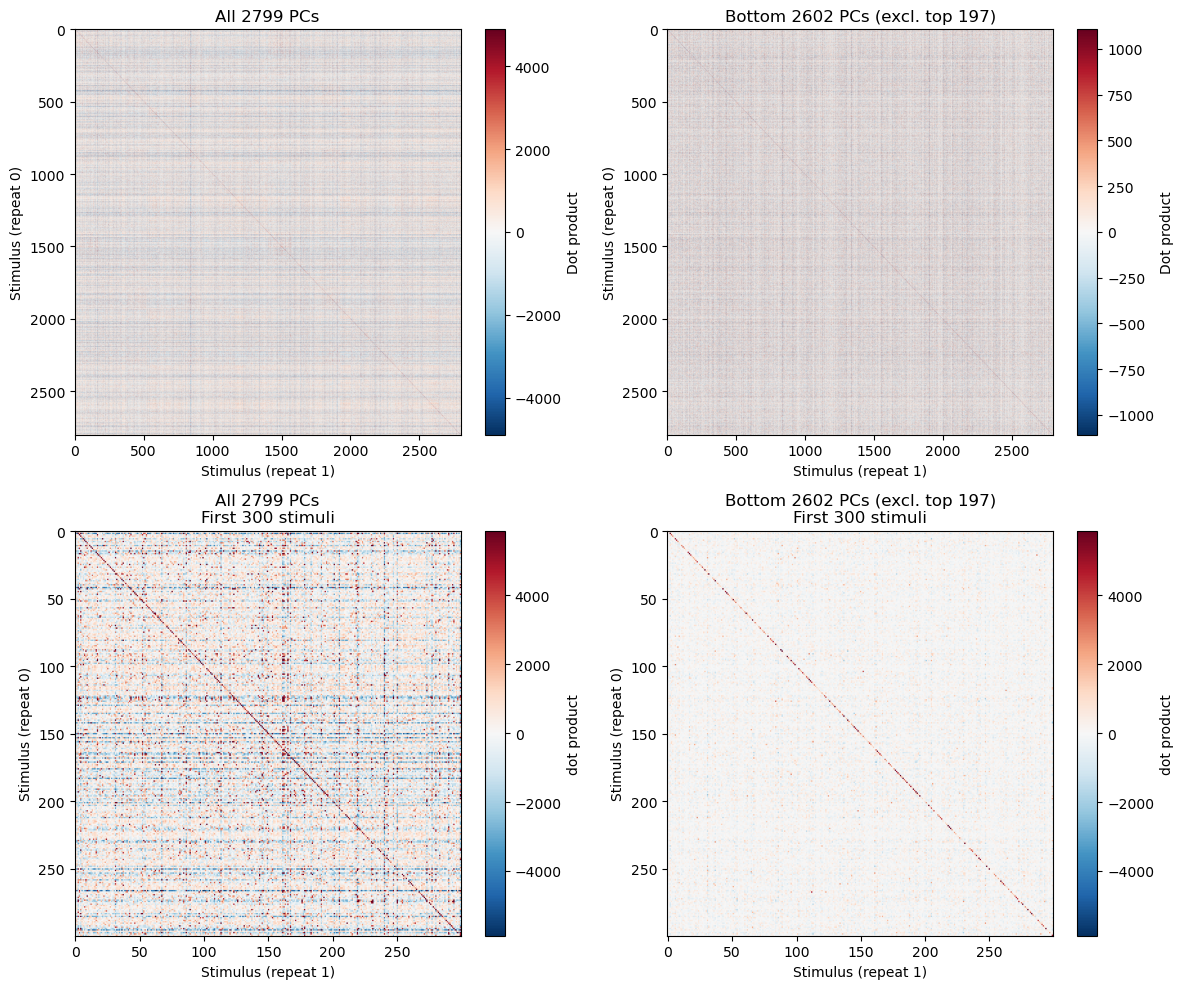

In [8]:
# cc heatmap: all PCs vs bottom 2602 PCs
n_top_exclude = n_pc - 2602  # 197

# Compute dot product matrices for all PCs
cc_all = scores0 @ scores1.T
#  and bottom 2602 PCs
cc_bot = scores0[:, n_top_exclude:] @ scores1[:, n_top_exclude:].T

zoom = 300   # subset of stimuli to zoom in on for the second row of panels

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

panels = [
    (cc_all, f'All {n_pc} PCs'),
    (cc_bot, f'Bottom 2602 PCs (excl. top {n_top_exclude})'),
]

for col, (mat, title) in enumerate(panels):
    # Full matrix (uses own colour scale)
    vlim = np.percentile(np.abs(mat), 99)          # colour limit: 99th percentile of absolute values, so extreme outliers don't compress the scale
    im = axes[0, col].imshow(mat, aspect='auto',   # render matrix as heatmap
                          cmap='RdBu_r',           # diverging red-blue colormap — negative=blue, zero=white, positive=red
                          vmin=-vlim, vmax=vlim) 
    fig.colorbar(im, ax=axes[0, col], label='Dot product')  # add colour scale bar on the right
    axes[0, col].set_xlabel('Stimulus (repeat 1)')
    axes[0, col].set_ylabel('Stimulus (repeat 0)') 
    axes[0, col].set_title(title)                   # panel title

    # Zoomed — shared colour scale between the two zoomed panels
    axes[1, col].set_title(f'{title}\nFirst {zoom} stimuli')
    axes[1, col].set_xlabel('Stimulus (repeat 1)')
    axes[1, col].set_ylabel('Stimulus (repeat 0)')

# shared vlim for zoomed panels so diagonal contrast is comparable
vlim_zoom = max(np.percentile(np.abs(cc_all[:zoom, :zoom]), 99),
                np.percentile(np.abs(cc_bot[:zoom, :zoom]), 99))


for col, mat in enumerate([cc_all, cc_bot]):
    im = axes[1, col].imshow(mat[:zoom, :zoom], aspect='auto',
                             cmap='RdBu_r', vmin=-vlim_zoom, vmax=vlim_zoom)
    fig.colorbar(im, ax=axes[1, col], label='dot product')

plt.tight_layout()
plt.savefig('Fig3b.png')
plt.show()

### 3c. Compare three similarity metrics for top-k vs bottom-k PC decoding:
Because we observed that the dot product decoder causes certain stimuli to correlate strongly with other stimuli simply due to it's magnitued, we wanted to test other decoders that either normalize each PC by its standard deviation (Mahalanobis), or normalize each stimulus vector in PC space (cosine similarity) to prevent certain stimuli from dominating. 

Raw dot product  — variance-weighted (top PCs dominate)

Mahalanobis      — each PC normalised by its std → equal per-dimension weight

Cosine similarity        — each stimulus vector normalised → removes magnitude bias

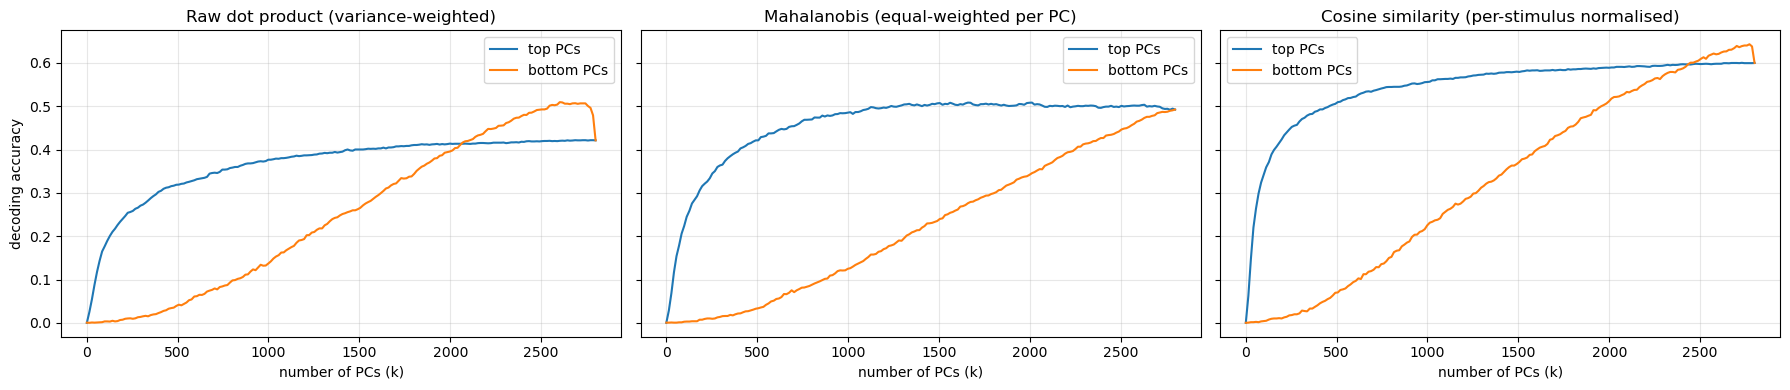

In [ ]:
# Mahalanobis
std  = scores0.std(axis=0) + 1e-12    # per-PC standard deviation of stim. scores along each PC (from repeat 0)
scores0_m = scores0 / std                                          
scores1_m = scores1 / std

# Cosine (per-stimulus)
norm0 = np.linalg.norm(scores0, axis=1, keepdims=True) + 1e-12    # scalar norm of each PC response vector
norm1 = np.linalg.norm(scores1, axis=1, keepdims=True) + 1e-12
scores0_c = scores0 / norm0      # normalize PC scores by stimulus norms                                   
scores1_c = scores1 / norm1

ks = np.round(np.linspace(1, n_pc, 200)).astype(int)

acc = {name: {'top': np.zeros(len(ks)), 'bot': np.zeros(len(ks))}
       for name in ('raw', 'mah', 'cos')}

for i, k in enumerate(ks):
    for name, s0, s1 in [('raw', scores0,   scores1  ),
                          ('mah', scores0_m, scores1_m),
                          ('cos', scores0_c, scores1_c)]:
        cc = s0[:, :k]  @ s1[:, :k].T
        acc[name]['top'][i] = (cc.argmax(axis=1) == np.arange(nstims)).mean()
        cc = s0[:, -k:] @ s1[:, -k:].T
        acc[name]['bot'][i] = (cc.argmax(axis=1) == np.arange(nstims)).mean()

titles = {'raw': 'Raw dot product (variance-weighted)',
          'mah': 'Mahalanobis (equal-weighted per PC)',
          'cos': 'Cosine similarity (per-stimulus normalised)'}

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, name in zip(axes, ('raw', 'mah', 'cos')):
    ax.plot(ks, acc[name]['top'], color='C0', label='top PCs')
    ax.plot(ks, acc[name]['bot'], color='C1', label='bottom PCs')
    ax.set_title(titles[name])
    ax.set_xlabel('number of PCs (k)')
    ax.legend()
    ax.grid(alpha=0.3)

axes[0].set_ylabel('decoding accuracy')
plt.tight_layout()
plt.savefig('Fig3c.png')
plt.show()

## 4. Cosine similarity decoder: top vs. bottom PCs across all mice
Using cosine similarity (each stimulus vector normalised), because it had the best accuracy in part 3c. 

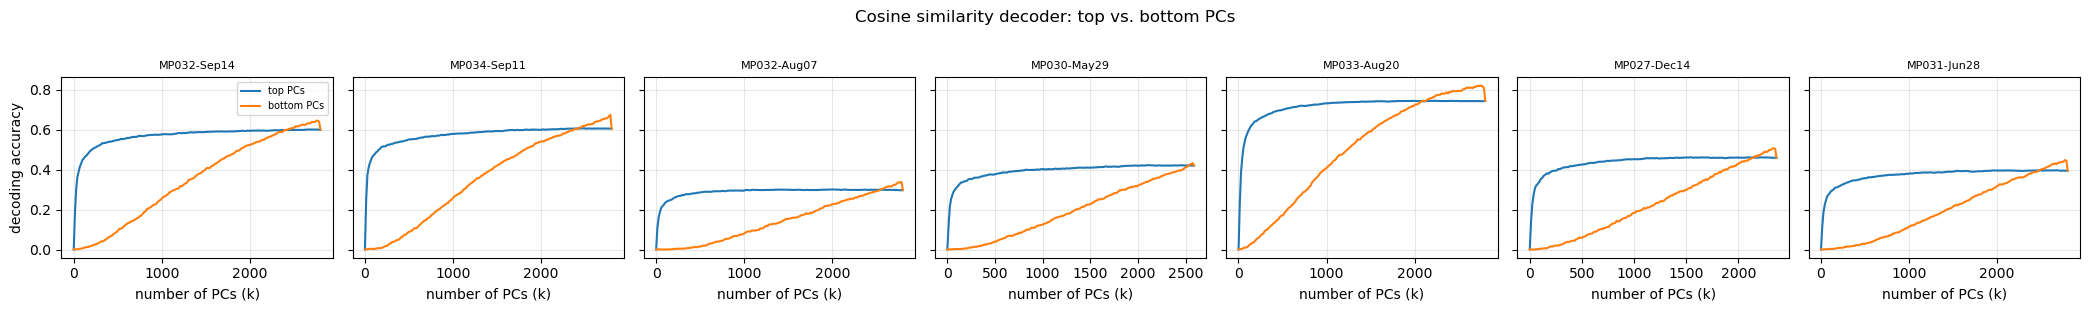

In [10]:
# Plot 4: cosine similarity decoder, top vs bottom PCs, one subplot per mouse
fig, axes = plt.subplots(1, 7, figsize=(21, 3), sharey=True)

for ax, d, label in zip(axes, datasets, mouse_ids):
    sresp, scores0, scores1, n_pc, nstims = preprocess(d)

    ks = np.round(np.linspace(1, n_pc, 200)).astype(int)
    acc_top = np.zeros(len(ks))
    acc_bottom = np.zeros(len(ks))

    for i, k in enumerate(ks):
        # Top k PCs
        s0 = scores0[:, :k]
        s1 = scores1[:, :k]
        s0 = s0 / (np.linalg.norm(s0, axis=1, keepdims=True) + 1e-12)
        s1 = s1 / (np.linalg.norm(s1, axis=1, keepdims=True) + 1e-12)
        cc = s0 @ s1.T
        acc_top[i] = (cc.argmax(axis=1) == np.arange(nstims)).mean()

        # Bottom k PCs
        s0 = scores0[:, -k:]
        s1 = scores1[:, -k:]
        s0 = s0 / (np.linalg.norm(s0, axis=1, keepdims=True) + 1e-12)
        s1 = s1 / (np.linalg.norm(s1, axis=1, keepdims=True) + 1e-12)
        cc = s0 @ s1.T
        acc_bottom[i] = (cc.argmax(axis=1) == np.arange(nstims)).mean()

    ax.plot(ks, acc_top,    color='C0', label='top PCs')
    ax.plot(ks, acc_bottom, color='C1', label='bottom PCs')
    ax.set_title(label, fontsize=8)
    ax.set_xlabel('number of PCs (k)')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('decoding accuracy')
axes[0].legend(fontsize=7)
fig.suptitle('Cosine similarity decoder: top vs. bottom PCs', y=1.02)
plt.tight_layout()
plt.savefig('Fig4.png')
plt.show()